In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [3]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [4]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.943023,-0.584754,4.977809,1.205175,-3.068198,0
1,0.811505,-0.719252,-0.013917,-2.821138,-0.603037,0
2,1.550794,0.169920,0.422146,-1.724059,-0.764983,0
3,1.990473,-0.426048,1.633259,-0.751496,-1.593908,0
4,-0.802706,-1.122853,-1.914170,0.536151,1.015455,1


In [9]:
df.sample(10)

,col1,col2,col3,col4,col5,target
34,-1.502821,-0.980983,-1.119833,1.301563,1.180064,1
86,-0.659013,-0.542548,3.565071,0.542771,-4.078952,0
11,-1.502590,-0.814069,-1.561397,1.437396,1.751836,1
99,-0.038159,2.729762,0.713310,-0.904569,-0.014314,0
6,-1.245999,-1.527701,-1.712921,1.632053,1.726245,1
53,-1.328622,-0.369398,-1.329920,-0.075426,0.673911,1
30,-0.254933,0.203714,1.294155,-1.682573,-0.671733,0
72,-3.181322,0.787040,-0.685597,1.152832,1.751594,1
27,0.560145,-2.479703,0.737382,-3.576110,0.589609,0
4,-0.802706,-1.122853,-1.914170,0.536151,1.015455,1


In [8]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [16]:
df.columns.tolist()[:-1]

['col1', 'col2', 'col3', 'col4', 'col5']

## 1.এটা হলো Pandas Index object।

In [21]:
df.shape[1]-1

5

## df.shape = (row, column)
             ↓      ↓
           [0]    [1]

## random.sample(list, কতগুলো নিতে চাই)

In [25]:
# function for feature sampling
import random
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [23]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [26]:
df1 = combined_sampling(df,0.5,0.5)

In [28]:
df2 = combined_sampling(df,0.5,0.5)

In [27]:
df3 = combined_sampling(df,0.5,0.5)

In [29]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col2', 'col5', 'target'], dtype='str')
Index(['col3', 'col1', 'target'], dtype='str')
Index(['col4', 'col5', 'target'], dtype='str')


In [31]:
df3.shape

(50, 3)

In [32]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [33]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [34]:
from sklearn.tree import plot_tree

[Text(0.5555555555555556, 0.9, 'x[0] <= -0.782\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.3333333333333333, 0.7, 'x[1] <= -0.959\ngini = 0.172\nsamples = 21\nvalue = [2, 19]'),
 Text(0.4444444444444444, 0.8, 'True  '),
 Text(0.2222222222222222, 0.5, 'x[1] <= -0.987\ngini = 0.444\nsamples = 6\nvalue = [2, 4]'),
 Text(0.1111111111111111, 0.3, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.3333333333333333, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.4444444444444444, 0.5, 'gini = 0.0\nsamples = 15\nvalue = [0, 15]'),
 Text(0.7777777777777778, 0.7, 'x[1] <= 1.264\ngini = 0.238\nsamples = 29\nvalue = [25, 4]'),
 Text(0.6666666666666667, 0.8, '  False'),
 Text(0.6666666666666666, 0.5, 'x[0] <= -0.009\ngini = 0.137\nsamples = 27\nvalue = [25, 2]'),
 Text(0.5555555555555556, 0.3, 'x[0] <= -0.424\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.4444444444444444, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.6666666666666666, 0.1, 'gini = 0.0\nsam

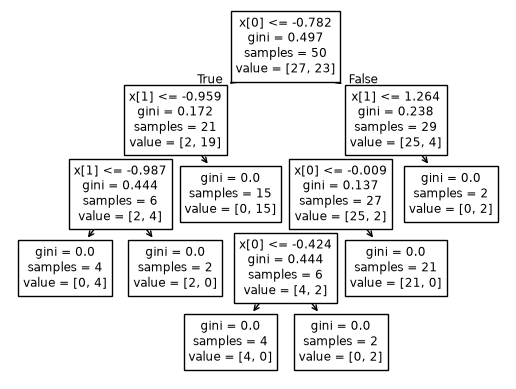

In [35]:
plot_tree(clf1)

[Text(0.5, 0.8333333333333334, 'x[0] <= -0.038\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.25, 0.5, 'x[1] <= 1.373\ngini = 0.219\nsamples = 32\nvalue = [4, 28]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.0\nsamples = 28\nvalue = [0, 28]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.75, 0.5, 'x[1] <= -1.068\ngini = 0.105\nsamples = 18\nvalue = [17, 1]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]')]

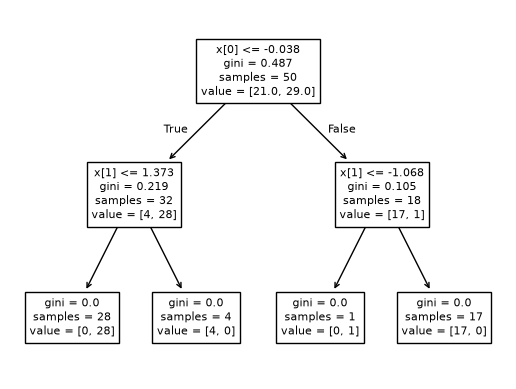

In [36]:
plot_tree(clf2)

[Text(251.10000000000002, 199.32, 'X[0] <= -0.208\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(209.25, 163.07999999999998, 'X[1] <= -1.513\ngini = 0.271\nsamples = 31\nvalue = [5, 26]'),
 Text(167.4, 126.83999999999999, 'X[1] <= -1.558\ngini = 0.486\nsamples = 12\nvalue = [5, 7]'),
 Text(125.55000000000001, 90.6, 'X[1] <= -1.972\ngini = 0.219\nsamples = 8\nvalue = [1, 7]'),
 Text(83.7, 54.359999999999985, 'X[1] <= -2.141\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(41.85, 18.119999999999976, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(125.55000000000001, 18.119999999999976, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(167.4, 54.359999999999985, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(209.25, 90.6, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(251.10000000000002, 126.83999999999999, 'gini = 0.0\nsamples = 19\nvalue = [0, 19]'),
 Text(292.95, 163.07999999999998, 'gini = 0.0\nsamples = 19\nvalue = [19, 0]')]

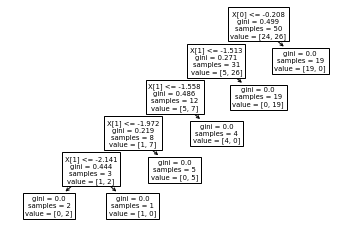

In [140]:
plot_tree(clf3)

## এখানে মূল কাজ হলো 1D NumPy array-কে 2D array-তে convert করা, যাতে Machine Learning model-এ input হিসেবে দেওয়া যায়।

In [37]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [38]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [39]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [40]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
37,0.675455,0.554263,1.416822,-0.412368,-3.090043,0
9,-1.083091,0.275626,2.869842,-0.241907,-2.791785,0
86,-0.659013,-0.542548,3.565071,0.542771,-4.078952,0
10,-1.585400,-0.930879,-0.478083,2.334816,1.285564,1
39,0.063937,-1.225817,-0.941639,0.200307,0.111999,1
53,-1.328622,-0.369398,-1.329920,-0.075426,0.673911,1
42,-1.840234,-0.556936,-2.518144,1.525480,3.630210,1
86,-0.659013,-0.542548,3.565071,0.542771,-4.078952,0
27,0.560145,-2.479703,0.737382,-3.576110,0.589609,0
46,0.545291,1.521685,2.104498,-0.512837,-0.100064,0
